# Resume-JD Deep Neural Network Match Scorer (Siamese BiLSTM)

Full pipeline: raw text -> cleaning -> tokenization (TextVectorization) -> padding -> shared Embedding layer -> shared BiLSTM (resume side + JD side) -> resume vector (u) / JD vector (v) -> similarity features -> Dense neural network -> softmax output -> loss calculation -> **backpropagation** -> **optimizer step** (handled internally by `model.fit()`) -> repeat for every batch -> repeat for every **epoch** -> final trained model.

**Labels**
- 0 = Weak Match (JD paired with a resume from a different record)
- 1 = Medium Match (JD paired with its own Resume-unmatched)
- 2 = Strong Match (JD paired with its own Resume-matched)

Just run all cells top to bottom in Google Colab (**Runtime -> Run all**). Upload `train.jsonl` when prompted (or place it in your Google Drive / Colab session storage first). Set `SOURCE_ROW_LIMIT = 3000` near section 3 for a quick end-to-end test before running the full 50k-row dataset.

## 0. Setup

In [ ]:
import os, json, re, random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, auc,
    precision_recall_fscore_support,
)
from sklearn.preprocessing import label_binarize

import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.layers import (
    Input, TextVectorization, Embedding, Bidirectional, LSTM,
    GlobalMaxPooling1D, Dense, Dropout, Concatenate, Lambda,
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, CSVLogger

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

OUTPUT_DIR = Path("outputs")
MODEL_DIR = Path("models")
OUTPUT_DIR.mkdir(exist_ok=True)
MODEL_DIR.mkdir(exist_ok=True)

## 1. Load train.jsonl

In [ ]:
DATA_CANDIDATES = [
    Path("/content/train.jsonl"),
    Path("/content/drive/MyDrive/train.jsonl"),
    Path("train.jsonl"),
]
DATA_PATH = next((p for p in DATA_CANDIDATES if p.exists()), None)

if DATA_PATH is None:
    try:
        from google.colab import files
        uploaded = files.upload()
        DATA_PATH = Path(next(iter(uploaded.keys())))
    except Exception as exc:
        raise FileNotFoundError(
            "train.jsonl not found. Upload it or update DATA_PATH."
        ) from exc

print("Using dataset:", DATA_PATH)


def read_jsonl(path):
    records = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    return records


records = read_jsonl(DATA_PATH)
print("Source rows:", len(records))
print("Fields:", list(records[0].keys()))

Saving train.jsonl to train.jsonl
Using dataset: train.jsonl
Source rows: 50000
Fields: ['Job-Description', 'Resume-matched', 'Resume-unmatched', 'Skills', 'Experiences', 'Experiences-years', 'Filtered-information']


## 2. Text cleaning

In [ ]:
def clean_text(text):
    text = str(text)
    text = re.sub(r"#+", " ", text)          # markdown headers
    text = re.sub(r"[-*•]", " ", text)        # bullet symbols
    text = re.sub(r"http\S+", " ", text)      # stray URLs
    text = re.sub(r"\s+", " ", text)          # collapse whitespace
    return text.strip()

## 3. Build Weak / Medium / Strong pairs

In [ ]:
LABEL_NAMES = {0: "Weak Match", 1: "Medium Match", 2: "Strong Match"}
LABEL_COLORS = {0: "#e74c3c", 1: "#f39c12", 2: "#27ae60"}

# Set a smaller number (e.g. 5000) while testing, None to use all 50k rows.
SOURCE_ROW_LIMIT = None


def build_labeled_pairs(source_records, row_limit=None, seed=SEED):
    if row_limit is not None:
        source_records = source_records[:row_limit]

    rng = random.Random(seed)
    matched_resumes = [clean_text(r["Resume-matched"]) for r in source_records]
    shuffled_resumes = matched_resumes.copy()
    rng.shuffle(shuffled_resumes)

    for i in range(len(shuffled_resumes)):
        if shuffled_resumes[i] == matched_resumes[i]:
            j = (i + 1) % len(shuffled_resumes)
            shuffled_resumes[i], shuffled_resumes[j] = shuffled_resumes[j], shuffled_resumes[i]

    rows = []
    for idx, record in enumerate(source_records):
        jd = clean_text(record["Job-Description"])
        rows.append({"resume_text": clean_text(record["Resume-matched"]),
                      "job_description": jd, "match_label": 2, "label_name": LABEL_NAMES[2]})
        rows.append({"resume_text": clean_text(record["Resume-unmatched"]),
                      "job_description": jd, "match_label": 1, "label_name": LABEL_NAMES[1]})
        rows.append({"resume_text": shuffled_resumes[idx],
                      "job_description": jd, "match_label": 0, "label_name": LABEL_NAMES[0]})
    return pd.DataFrame(rows)


df = build_labeled_pairs(records, row_limit=SOURCE_ROW_LIMIT)
df = df.sample(frac=1.0, random_state=SEED).reset_index(drop=True)

print(df.shape)
print(df["label_name"].value_counts())
df.head()

(150000, 4)
label_name
Medium Match    50000
Weak Match      50000
Strong Match    50000
Name: count, dtype: int64


,resume_text,job_description,match_label,label_name
0,Personal Information Name: Junaidi Mannan Emai...,Job title Laborers and freight stock and mater...,1,Medium Match
1,Personal Information Name: Saar Steiner Email:...,Job title Manager QA Automation Management Tea...,0,Weak Match
2,Personal Information Name: Mei hui Lee Email: ...,Job title Postsecondary Political Science Prof...,1,Medium Match
3,Personal Information Name: Gabor Smith Email: ...,Job Title Phone Interview for Sr. Netapp Consu...,1,Medium Match
4,Personal Information Name: Oumou Sissoko Email...,Job title Lead Security Engineer Infrastructur...,2,Strong Match


## 3b. Exploratory graphs — class balance + text length histograms

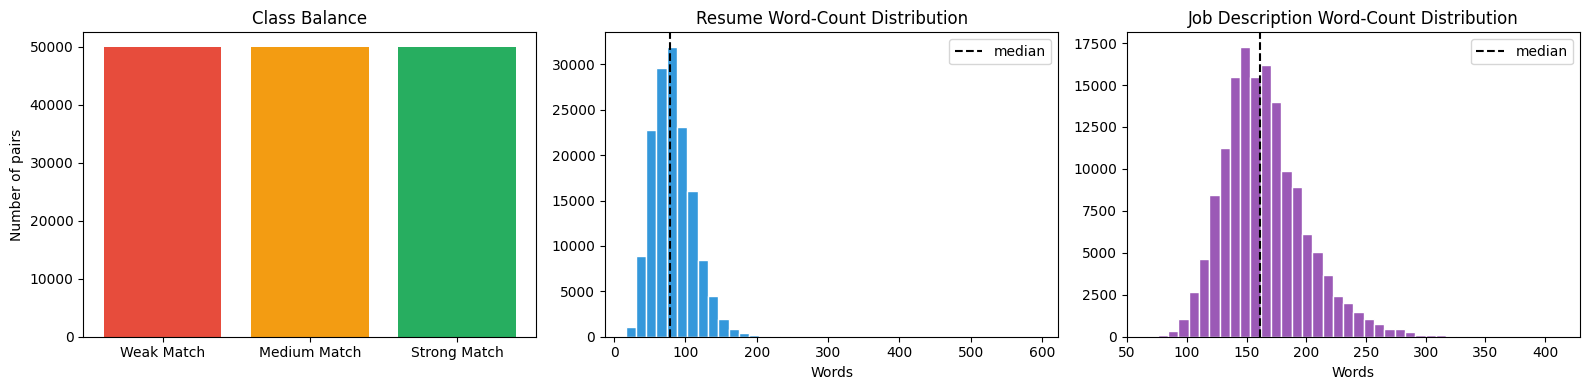

In [ ]:
df["resume_word_count"] = df["resume_text"].str.split().apply(len)
df["jd_word_count"] = df["job_description"].str.split().apply(len)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# class balance bar chart
counts = df["label_name"].value_counts().reindex([LABEL_NAMES[i] for i in range(3)])
axes[0].bar(counts.index, counts.values, color=[LABEL_COLORS[i] for i in range(3)])
axes[0].set_title("Class Balance")
axes[0].set_ylabel("Number of pairs")

# resume length histogram
axes[1].hist(df["resume_word_count"], bins=40, color="#3498db", edgecolor="white")
axes[1].axvline(df["resume_word_count"].median(), color="black", linestyle="--", label="median")
axes[1].set_title("Resume Word-Count Distribution")
axes[1].set_xlabel("Words"); axes[1].legend()

# JD length histogram
axes[2].hist(df["jd_word_count"], bins=40, color="#9b59b6", edgecolor="white")
axes[2].axvline(df["jd_word_count"].median(), color="black", linestyle="--", label="median")
axes[2].set_title("Job Description Word-Count Distribution")
axes[2].set_xlabel("Words"); axes[2].legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "eda_overview.png", dpi=160)
plt.show()

## 4. Train / Validation / Test split

In [ ]:
train_df, temp_df = train_test_split(
    df, test_size=0.20, random_state=SEED, stratify=df["match_label"]
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=SEED, stratify=temp_df["match_label"]
)

print("Train:", train_df.shape, "Val:", val_df.shape, "Test:", test_df.shape)

Train: (120000, 6) Val: (15000, 6) Test: (15000, 6)


## 5. Tokenization + padding (TextVectorization)

Vocabulary size: 30000


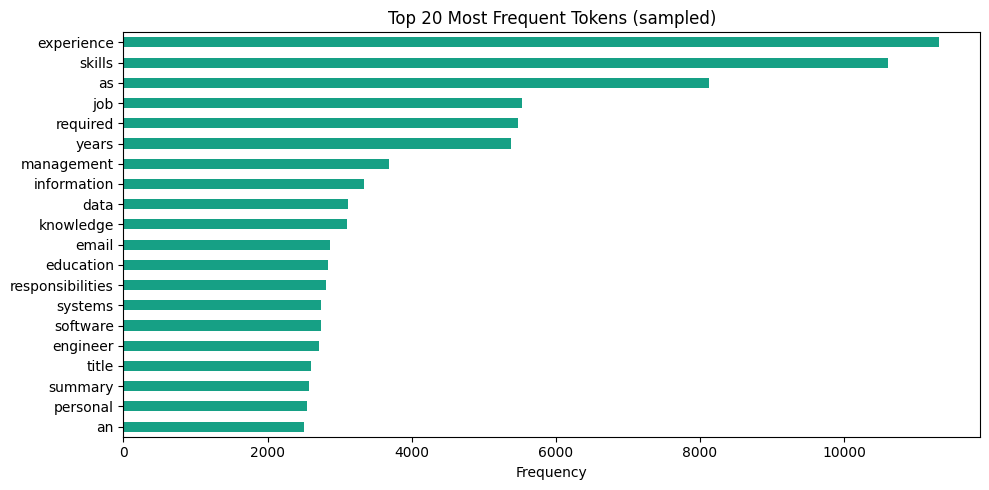

In [ ]:
MAX_TOKENS = 30000
MAX_LEN = 320
EMBED_DIM = 128

vectorizer = TextVectorization(
    max_tokens=MAX_TOKENS,
    output_mode="int",
    output_sequence_length=MAX_LEN,
    standardize="lower_and_strip_punctuation",
)

all_training_text = pd.concat(
    [train_df["resume_text"], train_df["job_description"]], ignore_index=True
)
vectorizer.adapt(all_training_text.to_numpy())

vocab_size = len(vectorizer.get_vocabulary())
print("Vocabulary size:", vocab_size)

# vocabulary frequency graph (top 20 non-trivial tokens)
vocab = vectorizer.get_vocabulary()
sample_text = " ".join(all_training_text.sample(5000, random_state=SEED).tolist())
tokens = re.findall(r"[a-z]+", sample_text.lower())
freq = pd.Series(tokens).value_counts().drop(
    labels=[t for t in ["the", "and", "for", "with", "to", "of", "in", "a", "is"] if t in pd.Series(tokens).value_counts().index],
    errors="ignore",
).head(20)

plt.figure(figsize=(10, 5))
freq.sort_values().plot(kind="barh", color="#16a085")
plt.title("Top 20 Most Frequent Tokens (sampled)")
plt.xlabel("Frequency")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "top_tokens.png", dpi=160)
plt.show()


def make_dataset(dataframe, shuffle=False, batch_size=32):
    resume = dataframe["resume_text"].astype(str).to_numpy()
    jd = dataframe["job_description"].astype(str).to_numpy()
    labels = dataframe["match_label"].astype("int32").to_numpy()
    ds = tf.data.Dataset.from_tensor_slices(((resume, jd), labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(dataframe), seed=SEED)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)


BATCH_SIZE = 32
train_ds = make_dataset(train_df, shuffle=True, batch_size=BATCH_SIZE)
val_ds = make_dataset(val_df, batch_size=BATCH_SIZE)
test_ds = make_dataset(test_df, batch_size=BATCH_SIZE)

## 6. Siamese BiLSTM model

In [ ]:
def build_siamese_bilstm_model(vocab_size, embed_dim=128):
    resume_input = Input(shape=(), dtype=tf.string, name="resume_text")
    jd_input = Input(shape=(), dtype=tf.string, name="job_description")

    embedding = Embedding(input_dim=vocab_size, output_dim=embed_dim,
                           mask_zero=True, name="shared_embedding")
    bilstm = Bidirectional(LSTM(64, return_sequences=True), name="shared_bilstm")
    pool = GlobalMaxPooling1D(name="global_max_pool")

    def encode(text_input):
        x = vectorizer(text_input)
        x = embedding(x)
        x = bilstm(x)
        x = pool(x)
        return x

    u = encode(resume_input)   # resume vector
    v = encode(jd_input)       # JD vector

    abs_diff = Lambda(lambda t: tf.abs(t[0] - t[1]), name="abs_difference")([u, v])
    product = Lambda(lambda t: t[0] * t[1], name="elementwise_product")([u, v])
    cosine_sim = Lambda(
        lambda t: tf.expand_dims(
            tf.reduce_sum(tf.nn.l2_normalize(t[0], axis=1) * tf.nn.l2_normalize(t[1], axis=1), axis=1),
            axis=1,
        ),
        name="cosine_similarity",
    )([u, v])

    features = Concatenate(name="comparison_features")([u, v, abs_diff, product, cosine_sim])

    x = Dense(128, activation="relu")(features)
    x = Dropout(0.30)(x)
    x = Dense(64, activation="relu")(x)
    output = Dense(3, activation="softmax", name="match_class")(x)

    return Model(inputs=[resume_input, jd_input], outputs=output)


model = build_siamese_bilstm_model(vocab_size=vocab_size, embed_dim=EMBED_DIM)
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'global_max_pool' (of type GlobalMaxPooling1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ resume_text         │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ job_description     │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_vectorization  │ (None, 320)       │          0 │ resume_text[0][0… │
│ (TextVectorization) │                   │            │ job_description[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_embedding    │ (None, 320, 128)  │  3,840,000 │ text_vectorizati… │
│ (Embedding)         │                   │            │ text_vectorizati… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 320)       │          0 │ text_vectorizati… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_1         │ (None, 320)       │          0 │ text_vectorizati… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_bilstm       │ (None, 320, 128)  │     98,816 │ shared_embedding… │
│ (Bidirectional)     │                   │            │ not_equal[0][0],  │
│                     │                   │            │ shared_embedding… │
│                     │                   │            │ not_equal_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pool     │ (None, 128)       │          0 │ shared_bilstm[0]… │
│ (GlobalMaxPooling1… │                   │            │ shared_bilstm[1]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ abs_difference      │ (None, 128)       │          0 │ global_max_pool[… │
│ (Lambda)            │                   │            │ global_max_pool[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ elementwise_product │ (None, 128)       │          0 │ global_max_pool[… │
│ (Lambda)            │                   │            │ global_max_pool[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cosine_similarity   │ (None, 1)         │          0 │ global_max_pool[… │
│ (Lambda)            │                   │            │ global_max_pool[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ comparison_features │ (None, 513)       │          0 │ global_max_pool[… │
│ (Concatenate)       │                   │            │ global_max_pool[… │
│                     │                   │            │ abs_difference[0… │
│                     │                   │            │ elementwise_prod… │
│                     │                   │            │ cosine_similarit… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │     65,792 │ comparison_featu… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      8,256 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ match_class (Dense) │ (None, 3)         │        195 │ dense_1[0][0]     │
└─────────────────────┴───────────────────┴────────────┴─────────────────

 Total params: 4,013,059 (15.31 MB)

 Trainable params: 4,013,059 (15.31 MB)

 Non-trainable params: 0 (0.00 B)

## 7. Train the model

   model.fit() runs exactly these steps internally, once per batch,
   repeated for every epoch:
     1. Forward pass       -> predictions = model(inputs)
     2. Loss calculation   -> loss_fn(labels, predictions)
     3. Backpropagation    -> gradients = tape.gradient(loss, weights)
     4. Optimizer step     -> optimizer.apply_gradients(...)
     5. Repeat over every batch in the dataset
     6. Repeat over every epoch (up to EPOCHS, or until EarlyStopping fires)
     7. Final trained model -> saved by ModelCheckpoint + model.save() below

In [ ]:
EPOCHS = 12
LEARNING_RATE = 0.001

model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss="sparse_categorical_crossentropy",   # loss calculation
    metrics=["accuracy"],
)

callbacks = [
    EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
    ModelCheckpoint(MODEL_DIR / "resume_jd_match_model.keras", monitor="val_loss", save_best_only=True),
    CSVLogger(OUTPUT_DIR / "training_log.csv"),
]

history_obj = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
)
history = history_obj.history

Epoch 1/12
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 159s 40ms/step - accuracy: 0.7991 - loss: 0.4251 - val_accuracy: 0.8607 - val_loss: 0.3074
Epoch 2/12
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 153s 41ms/step - accuracy: 0.8821 - loss: 0.2711 - val_accuracy: 0.8817 - val_loss: 0.2728
Epoch 3/12
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 150s 40ms/step - accuracy: 0.9169 - loss: 0.2018 - val_accuracy: 0.8849 - val_loss: 0.2725
Epoch 4/12
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 149s 40ms/step - accuracy: 0.9430 - loss: 0.1462 - val_accuracy: 0.8890 - val_loss: 0.2858
Epoch 5/12
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 150s 40ms/step - accuracy: 0.9597 - loss: 0.1061 - val_accuracy: 0.8911 - val_loss: 0.2844
Epoch 6/12
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 152s 40ms/step - accuracy: 0.9708 - loss: 0.0789 - val_accuracy: 0.8848 - val_loss: 0.3192


## 7b. Training curves

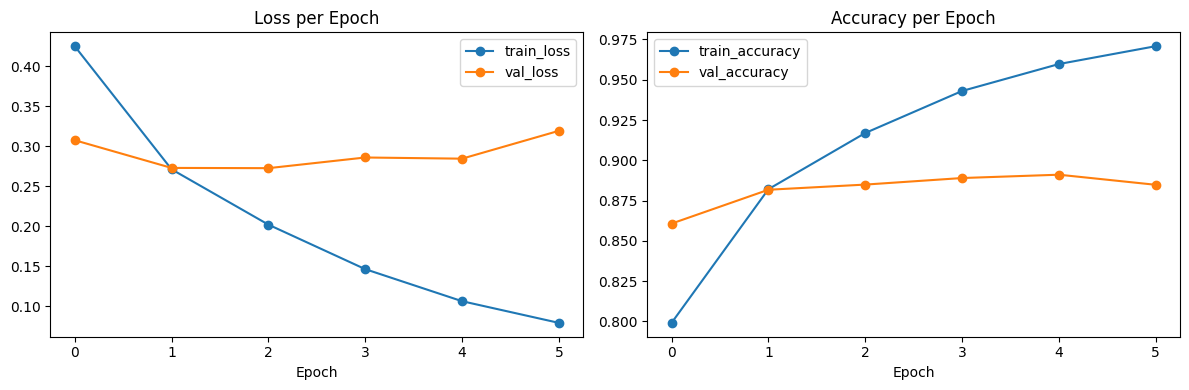

In [ ]:
hist_df = pd.DataFrame(history)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(hist_df["loss"], marker="o", label="train_loss")
axes[0].plot(hist_df["val_loss"], marker="o", label="val_loss")
axes[0].set_title("Loss per Epoch")
axes[0].set_xlabel("Epoch"); axes[0].legend()

axes[1].plot(hist_df["accuracy"], marker="o", label="train_accuracy")
axes[1].plot(hist_df["val_accuracy"], marker="o", label="val_accuracy")
axes[1].set_title("Accuracy per Epoch")
axes[1].set_xlabel("Epoch"); axes[1].legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "training_history.png", dpi=160)
plt.show()

## 8. Evaluate on the test set

469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.8796 - loss: 0.2790
Test loss: 0.2790
Test accuracy: 0.8796
  1/469 ━━━━━━━━━━━━━━━━━━━━ 3:38 467ms/step

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'global_max_pool' (of type GlobalMaxPooling1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step
              precision    recall  f1-score   support

  Weak Match     0.9832    0.9942    0.9887      5000
Medium Match     0.8766    0.7488    0.8077      5000
Strong Match     0.7895    0.8958    0.8393      5000

    accuracy                         0.8796     15000
   macro avg     0.8831    0.8796    0.8786     15000
weighted avg     0.8831    0.8796    0.8786     15000



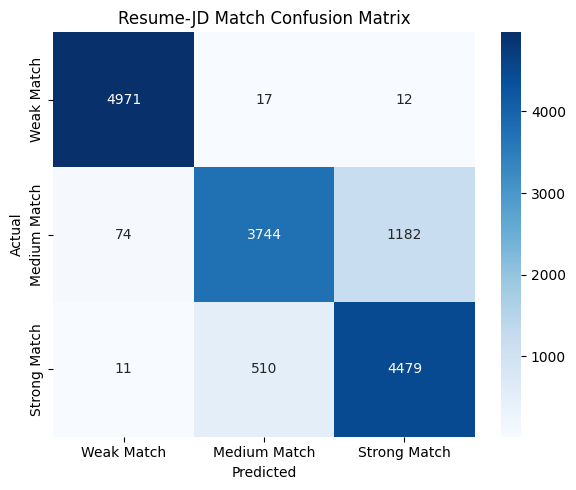

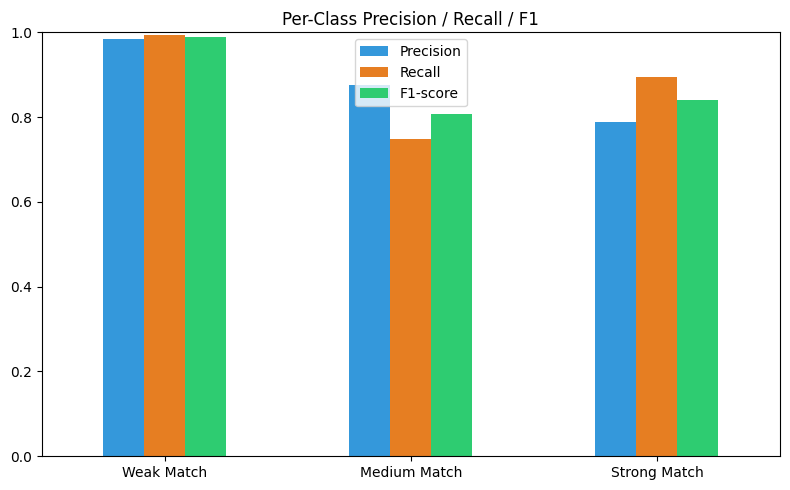

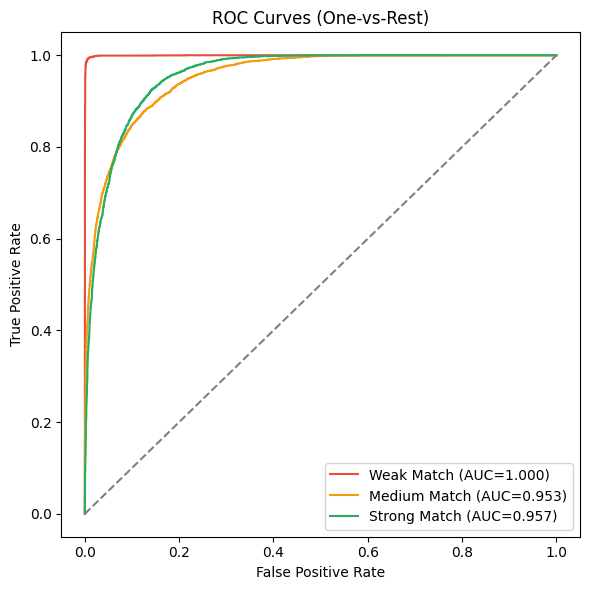

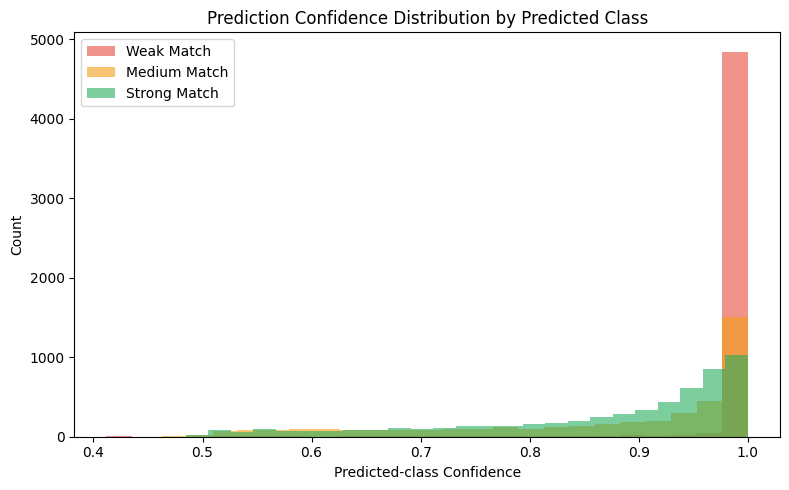

In [ ]:
test_loss, test_accuracy = model.evaluate(test_ds)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")

y_true = test_df["match_label"].to_numpy()
y_prob = model.predict(
    (test_df["resume_text"].astype(str).to_numpy(), test_df["job_description"].astype(str).to_numpy()),
    batch_size=BATCH_SIZE,
)
y_pred = np.argmax(y_prob, axis=1)

report = classification_report(
    y_true, y_pred, target_names=[LABEL_NAMES[i] for i in range(3)], digits=4
)
print(report)
with open(OUTPUT_DIR / "classification_report.txt", "w", encoding="utf-8") as f:
    f.write(report)

# --- confusion matrix ---
cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=[LABEL_NAMES[i] for i in range(3)],
            yticklabels=[LABEL_NAMES[i] for i in range(3)])
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title("Resume-JD Match Confusion Matrix")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confusion_matrix.png", dpi=160)
plt.show()

# --- per-class precision / recall / F1 bar chart ---
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, labels=[0, 1, 2])
metrics_df = pd.DataFrame(
    {"Precision": precision, "Recall": recall, "F1-score": f1},
    index=[LABEL_NAMES[i] for i in range(3)],
)
metrics_df.plot(kind="bar", figsize=(8, 5), color=["#3498db", "#e67e22", "#2ecc71"])
plt.title("Per-Class Precision / Recall / F1")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "per_class_metrics.png", dpi=160)
plt.show()

# --- ROC curves (one-vs-rest, multiclass) ---
y_true_bin = label_binarize(y_true, classes=[0, 1, 2])
plt.figure(figsize=(6, 6))
for i in range(3):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{LABEL_NAMES[i]} (AUC={roc_auc:.3f})", color=LABEL_COLORS[i])
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curves (One-vs-Rest)")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "roc_curves.png", dpi=160)
plt.show()

# --- prediction confidence histogram ---
confidences = y_prob[np.arange(len(y_pred)), y_pred]
plt.figure(figsize=(8, 5))
for i in range(3):
    mask = y_pred == i
    plt.hist(confidences[mask], bins=25, alpha=0.6, label=LABEL_NAMES[i], color=LABEL_COLORS[i])
plt.xlabel("Predicted-class Confidence"); plt.ylabel("Count")
plt.title("Prediction Confidence Distribution by Predicted Class")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confidence_histogram.png", dpi=160)
plt.show()

## 9. Predict + explain a single resume-JD pair

In [14]:
COMMON_SKILLS = [
    "python", "sql", "java", "javascript", "html", "css", "react", "node", "fastapi",
    "docker", "kubernetes", "aws", "azure", "gcp", "tensorflow", "keras", "pytorch",
    "machine learning", "deep learning", "nlp", "rag", "vector database", "mongodb",
    "postgresql", "spark", "etl", "tableau", "power bi", "excel", "linux", "git",
]


def extract_skills(text, skill_bank=COMMON_SKILLS):
    lowered = str(text).lower()
    return sorted({skill for skill in skill_bank if skill in lowered})

def predict_match(resume_text, job_description):
    resume_arr = np.array([resume_text], dtype=object)
    jd_arr = np.array([job_description], dtype=object)
    probabilities = model.predict((resume_arr, jd_arr), verbose=0)[0]
    predicted_class = int(np.argmax(probabilities))
    resume_skills = set(extract_skills(resume_text))
    jd_skills = set(extract_skills(job_description))
    return {
        "predicted_class": predicted_class,
        "predicted_label": LABEL_NAMES[predicted_class],
        "confidence": float(probabilities[predicted_class]),
        "probabilities": {LABEL_NAMES[i]: float(probabilities[i]) for i in range(3)},
        "common_skills": sorted(resume_skills & jd_skills),
        "missing_skills": sorted(jd_skills - resume_skills),
    }


sample = test_df.iloc[0]
result = predict_match(sample["resume_text"], sample["job_description"])
print(result)

prediction_markdown = f"""# Prediction Result

Predicted class: {result['predicted_label']}
Confidence: {result['confidence']:.2%}

Probabilities:
- Weak Match: {result['probabilities']['Weak Match']:.2%}
- Medium Match: {result['probabilities']['Medium Match']:.2%}
- Strong Match: {result['probabilities']['Strong Match']:.2%}

Common skills: {', '.join(result['common_skills']) if result['common_skills'] else 'None found'}
Missing skills: {', '.join(result['missing_skills']) if result['missing_skills'] else 'None found'}
"""
print(prediction_markdown)
with open(OUTPUT_DIR / "prediction_result.md", "w", encoding="utf-8") as f:
    f.write(prediction_markdown)

with open(OUTPUT_DIR / "class_mapping.json", "w", encoding="utf-8") as f:
    json.dump(LABEL_NAMES, f, indent=2)

{'predicted_class': 2, 'predicted_label': 'Strong Match', 'confidence': 0.7681039571762085, 'probabilities': {'Weak Match': 4.463413279154338e-05, 'Medium Match': 0.23185142874717712, 'Strong Match': 0.7681039571762085}, 'common_skills': [], 'missing_skills': []}
# Prediction Result

Predicted class: Strong Match
Confidence: 76.81%

Probabilities:
- Weak Match: 0.00%
- Medium Match: 23.19%
- Strong Match: 76.81%

Common skills: None found
Missing skills: None found



## 10. Save final trained model

In [15]:
model.save(MODEL_DIR / "resume_jd_match_model_final.keras")
print("Saved artifacts:")
print("-", MODEL_DIR / "resume_jd_match_model.keras", "(best epoch, checkpointed during training)")
print("-", MODEL_DIR / "resume_jd_match_model_final.keras", "(final trained model)")
print("-", OUTPUT_DIR / "eda_overview.png")
print("-", OUTPUT_DIR / "top_tokens.png")
print("-", OUTPUT_DIR / "training_history.png")
print("-", OUTPUT_DIR / "confusion_matrix.png")
print("-", OUTPUT_DIR / "per_class_metrics.png")
print("-", OUTPUT_DIR / "roc_curves.png")
print("-", OUTPUT_DIR / "confidence_histogram.png")
print("-", OUTPUT_DIR / "prediction_result.md")

Saved artifacts:
- models/resume_jd_match_model.keras (best epoch, checkpointed during training)
- models/resume_jd_match_model_final.keras (final trained model)
- outputs/eda_overview.png
- outputs/top_tokens.png
- outputs/training_history.png
- outputs/confusion_matrix.png
- outputs/per_class_metrics.png
- outputs/roc_curves.png
- outputs/confidence_histogram.png
- outputs/prediction_result.md
